In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the JSON responses
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_self_consistency.json', 'r') as file:
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/debug_responses/llama3_debug_bin_9_10_kernel_llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/MMT_Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# # Extract the answers from the DataFrame
true_answers = dict(zip(range(2787,2866), df['answer']))


In [26]:
responses_with_uncertainty['2819'].keys()

dict_keys(['prompt', 'responses', 'ground_truth_graph_llama3', 'kernel_matrix', 'avg_similarity_within_group', 'avg_similarity_with_ground_truth', 'uncertainty'])

In [85]:
# for idx, result in responses_with_uncertainty.items():
#     print(result.keys())

In [28]:
# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the JSON responses
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_io.json', 'r') as file:
#     responses_with_uncertainty = json.load(file)

# # Load the DataFrame with correct answers
# df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')

# # Extract the answers from the DataFrame using the 'index' column as keys
# true_answers = dict(zip(df['index'].astype(str), df['answer']))

# Initialize lists to store uncertainties and accuracies
confidences = []
accuracies = []
from tqdm import tqdm
# Extract data from responses_with_uncertainty

key_to_check_similarity = 'avg_similarity_within_group'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))
        # print(true_answer)
        # Calculate if the model's answer is correct
        # correct = any(response['answer'] == true_answer for response in responses)
        # Calcucalte how many answers are correct
        # print(response['answer'])
        # correct = sum(response['answer'] == true_answer for response in responses)
        # Calculate the number of correct answers
        # Calculate the number of correct answers
        print(responses)
        correct = 0
        for idx, response in enumerate(responses):
            try:
                true_answer = true_answers[int(idx)]
                print('True Answer:', true_answer)
                if response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"No true answer found for index {idx}.")
            except Exception as e:
                print(f"An error occurred: {e}")
        avg_accuracy = correct / len(responses)
        # Append the data to lists
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and convert nans to average uncertainty
confidences = np.array(confidences)
accuracies = np.array(accuracies)


100%|██████████| 11/11 [00:00<00:00, 4889.50it/s]

[{'answer': 'A', 'explanation': 'The man is wearing a pair of shorts in the image. The shorts are beige and have a grey pattern.', 'confidence': 1, 'graph_llama3': {'man': {'is wearing': {'description': 'state'}, 'image': {'description': 'in'}}, 'image': {}, 'shorts': {'beige': {'description': 'color'}, 'grey': {'description': 'pattern'}}, 'is wearing': {}, 'beige': {}, 'grey': {}}}, {'answer': {'A': 'shorts', 'B': 'long sleeve shirt', 'D': 'dress', 'E': 'flip flops'}, 'explanation': {'A': 'The man is wearing cargo shorts with patterned fabric. Shorts are an article of clothing specifically designed to cover the lower part of the body from waist to hem.'}, 'confidence': 1, 'graph_llama3': {'man': {'wearing': {'description': 'state'}, 'shorts': {'description': 'is wearing'}}, 'shorts': {'cargo': {'description': 'material'}, 'article of clothing': {'description': 'function'}, 'lower part of the body': {'description': 'body part'}, 'waist to hem': {'description': 'location'}}, 'fabric': {

In [20]:
accuracies 

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

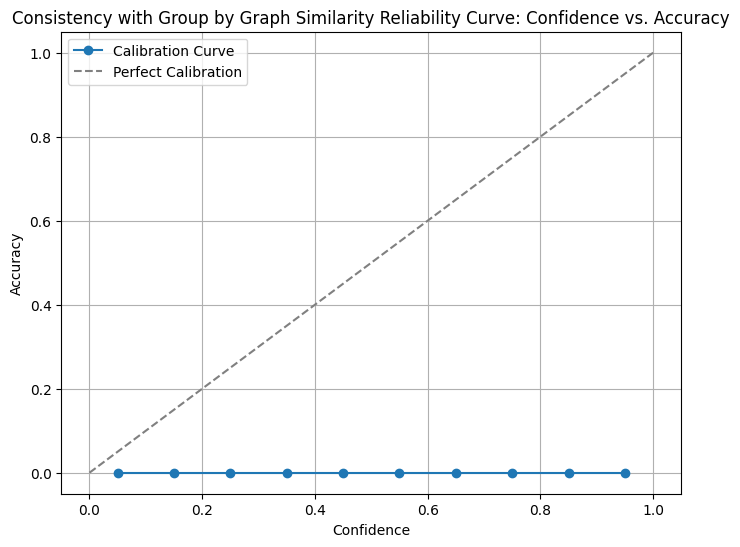

In [10]:
# remove nans
confidences_copy = confidences.copy()
confidences = confidences[~np.isnan(confidences_copy)]
accuracies = np.array(accuracies)[~np.isnan(confidences_copy)]
# uncertainties = 1 - uncertainties  # Convert uncertainty to confidence



# Bin data by uncertainty
def bin_data(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(confidences, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Consistency with Group by Graph Similarity Reliability Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(confidences, accuracies, num_bins=10)

Text(0, 0.5, 'Number of Samples')

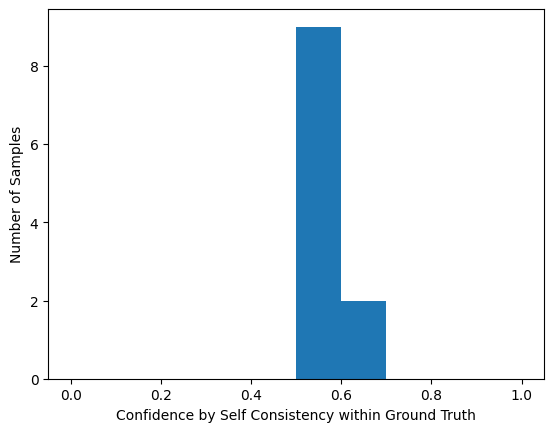

In [11]:
plt.hist(confidences, bins=np.linspace(0, 1, 11))
plt.xlabel('Confidence by Self Consistency within Ground Truth')
plt.ylabel('Number of Samples')

Text(0, 0.5, 'Number of Samples')

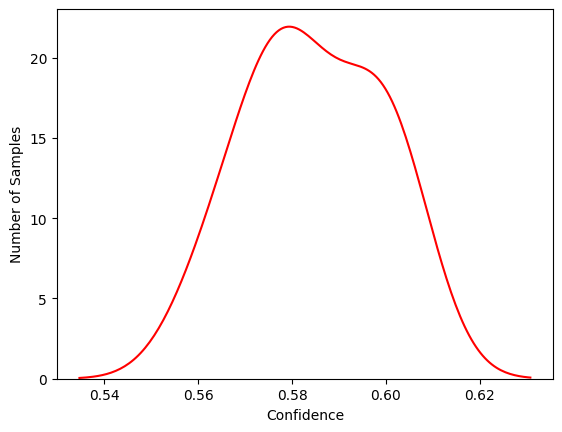

In [17]:
# plot the distribution of confidences
import seaborn as sns
sns.kdeplot(confidences, color='r')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')

/tmp/ipykernel_147734/2065359866.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(accuracies, color='r')


Text(0, 0.5, 'Number of Samples')

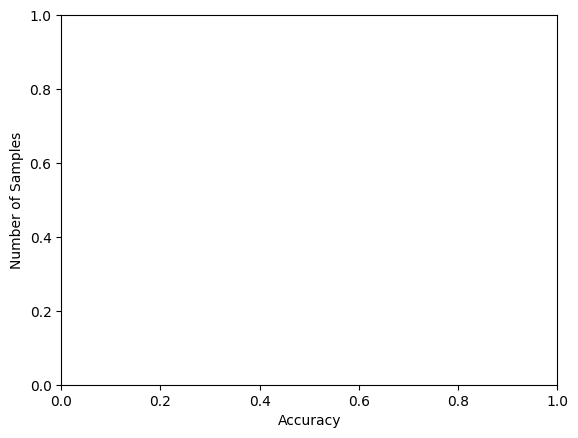

In [19]:
import seaborn as sns
sns.kdeplot(accuracies, color='r')
plt.xlabel('Accuracy')
plt.ylabel('Number of Samples')

In [15]:
!pip install seaborn

Text(0, 0.5, 'Number of Samples')

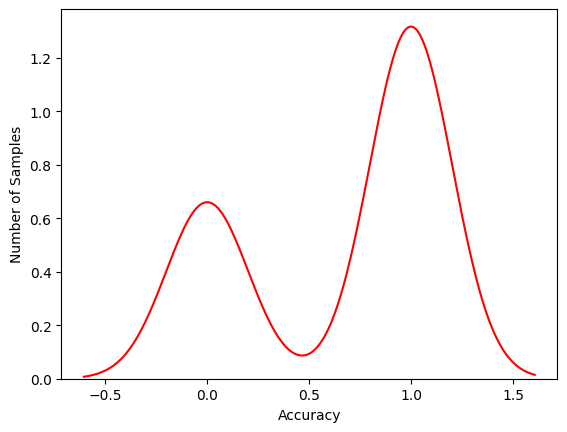

In [97]:
# plt.hist(accuracies, bins=np.linspace(0, 1, 11))
# draw a distribution of accuracies not in the bins
import seaborn as sns
sns.kdeplot(accuracies, color='r')
plt.xlabel('Accuracy')
plt.ylabel('Number of Samples')

In [99]:
avg_accuracy

0.0

In [23]:
# replace nan with 1
uncertainties = np.nan_to_num(uncertainties, nan=1.0)

In [42]:
1 - uncertainties

array([0.59506827, 0.61271772, 0.57925242, 0.58280602, 0.62760874,
       0.5900216 , 0.65583038, 0.61289924, 0.60469434, 0.61536226,
       0.6006882 , 0.57423584, 0.59086401, 0.61319302, 0.58797491,
       0.60530842, 0.61279526, 0.6007786 , 0.62670776, 0.59454707,
       0.58923217, 0.57821484, 0.6045605 , 0.59551646, 0.58457365,
       0.60486493, 0.59437153, 0.59195772, 0.60669037, 0.63122501,
       0.58168375, 0.60218977, 0.59765306, 0.60847236, 0.58939056,
       0.60318686, 0.62535363, 0.60116828, 0.5922053 , 0.59498589,
       0.5868585 , 0.59186807, 0.58425685, 0.5362034 , 0.57048297,
       0.60680972, 0.61083579, 0.59504206, 0.59605096, 0.60393711,
       0.58318893, 0.64720246, 0.57441305, 0.59945064, 0.58275636,
       0.58000155, 0.61756035, 0.749637  , 0.59500234, 0.58166617,
       0.61353631, 0.60318686, 0.60318686, 0.61397083, 0.61027293,
       0.60746705, 0.62977898, 0.60318686, 0.60318686, 0.61891936,
       0.62019786, 0.60318686, 0.60318686, 0.61950483, 0.60318

### Reliability Diagram for temp = 1, topp =1, and for MMT Dataset

In [24]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the JSON responses
# with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output1_uq_self_consistency.json', 'r') as file:
with open('/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the DataFrame with correct answers
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')
df = df[df['category'].str.contains('hallucination')]

# # Extract the answers from the DataFrame
true_answers = dict(zip(range(2787,2866), df['answer']))

FileNotFoundError: [Errno 2] No such file or directory: '/home/ubuntu/Multimodal-Uncertainty-Quantification/llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json'

In [9]:
# Initialize lists to store confidences and accuracies
confidences = []
accuracies = []
from tqdm import tqdm
# Extract data from responses_with_uncertainty

key_to_check_similarity = 'uncertainty'
for idx, result in tqdm(responses_with_uncertainty.items()):
    if key_to_check_similarity not in result and len(result['responses']) == 0:
        continue
    elif len(result['responses']) != 0:
        responses = result['responses']
        if key_to_check_similarity.lower() == 'uncertainty':
            confidence = 1 - result[key_to_check_similarity]
        else:
            confidence = result[key_to_check_similarity]
        true_answer = true_answers.get(int(idx))
        # print(true_answer)
        # Calculate if the model's answer is correct
        # correct = any(response['answer'] == true_answer for response in responses)
        # Calcucalte how many answers are correct
        # correct = sum(response['answer'] == true_answer for response in responses)
        # Calculate the number of correct answers
        # Calculate the number of correct answers
        correct = 0
        for response in responses:
            try:
                if isinstance(response, dict) and response['answer'] == true_answer:
                    correct += 1
            except KeyError:
                print(f"Response {response} does not contain 'answer' key. Skipping this response.")
            except TypeError:
                print(f"Unexpected data type in response: {response}. Skipping this response.")

        print(f"Number of correct answers: {correct}")
        print(f"Total number of responses: {len(responses)}")
        avg_accuracy = correct / len(responses)
        # Append the data to lists
        confidences.append(confidence)
        accuracies.append(avg_accuracy)

# Convert lists to NumPy arrays and convert nans to average uncertainty
confidences = np.array(confidences)
accuracies = np.array(accuracies)

100%|██████████| 80/80 [00:00<00:00, 32517.14it/s]

Number of correct answers: 5
Total number of responses: 16
Number of correct answers: 3
Total number of responses: 14
Response {'question': 'Which caption accurately orders car features (tub, flags, roof) and other contextual information (event/year, location)?', 'options': ['A', 'C', 'B', 'D'], 'explanation': "This caption is correct as it incorporates all accurate features (tub on the roof, flags attached) and situates the car in context (Mongol Rally) and time (2009). It mentions the car being decorated with flames, which is a car feature, but without a clear picture, it's not possible to validate this from the image. Additionally, it correctly places the year and event as the Mongol Rally in 2009."} does not contain 'answer' key. Skipping this response.
Response {'explanation': "The given image has cars lined up with decals and a racing theme, likely for the Mongol Rally. The caption that accurately reflects this scenario is 'C. With a tub resting on its outer roof, flags attached,

In [19]:
# accuracies

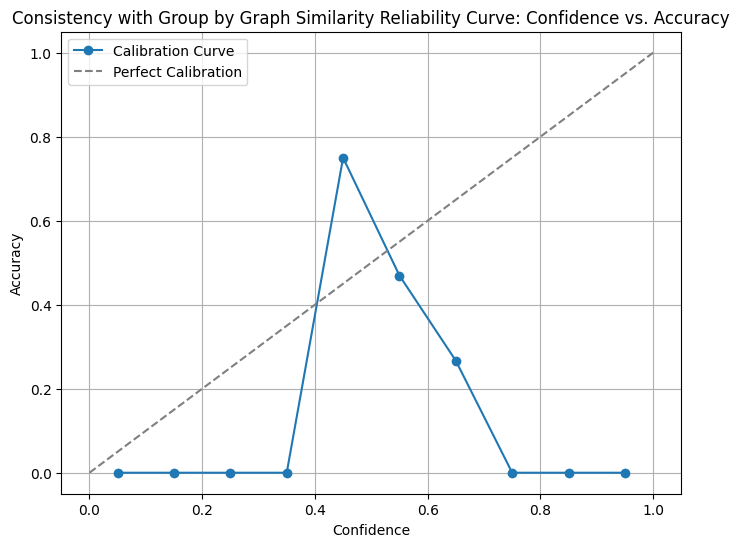

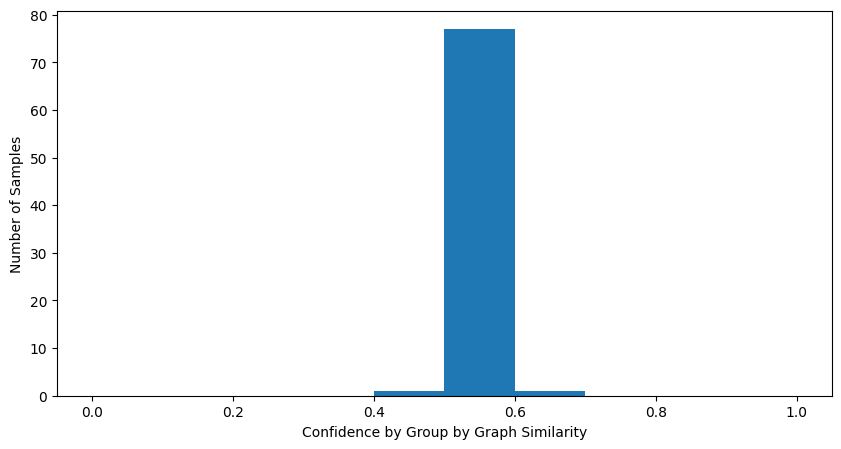

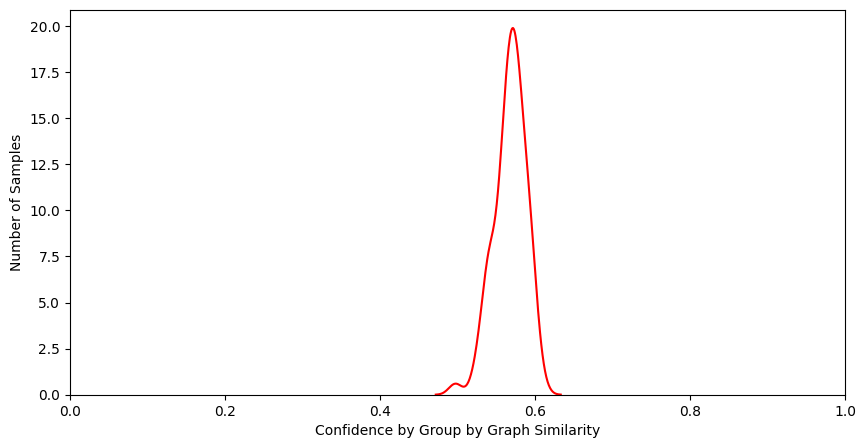

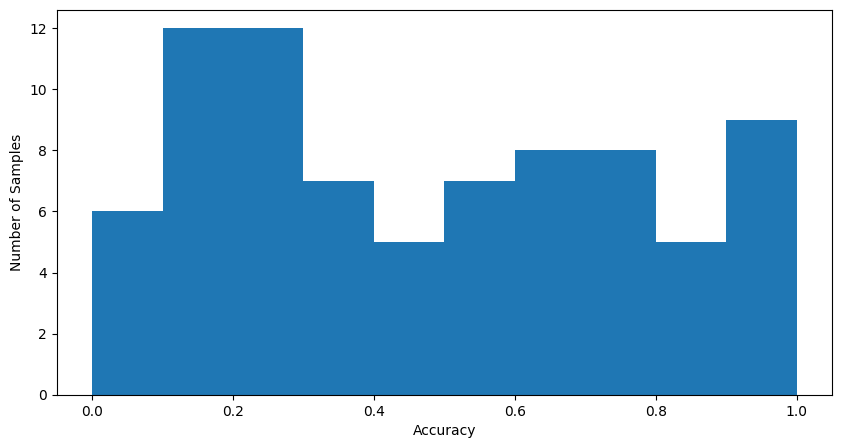

(0.0, 1.0)

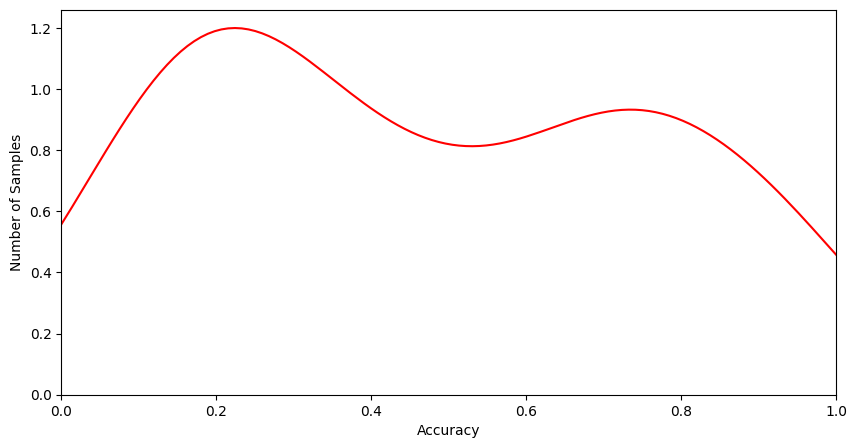

In [10]:
# remove nans
confidences_copy = confidences.copy()
confidences = confidences[~np.isnan(confidences_copy)]
accuracies = np.array(accuracies)[~np.isnan(confidences_copy)]
# uncertainties = 1 - uncertainties  # Convert uncertainty to confidence



# Bin data by uncertainty
def bin_data(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(confidences, accuracies, num_bins=10):
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Consistency with Group by Graph Similarity Reliability Curve: Confidence vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curve
plot_calibration_curve(confidences, accuracies, num_bins=10)
# Plot the histogram of confidences
plt.figure(figsize=(10, 5))
plt.hist(confidences, bins=np.linspace(0, 1, 11))
plt.xlabel('Confidence by Group by Graph Similarity')
plt.ylabel('Number of Samples')
plt.show()

# Plot the distribution of confidences
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.kdeplot(confidences, color='r')
plt.xlabel('Confidence by Group by Graph Similarity')
plt.ylabel('Number of Samples')
plt.xlim(0, 1)

# Plot the histogram of accuracies
plt.figure(figsize=(10, 5))
plt.hist(accuracies, bins=np.linspace(0, 1, 11))
plt.xlabel('Accuracy')
plt.ylabel('Number of Samples')
plt.show()
# plt.xlim(0, 1)

# plot the distribution of accuracies
plt.figure(figsize=(10, 5))
sns.kdeplot(accuracies, color='r')
plt.xlabel('Accuracy')
plt.ylabel('Number of Samples')
plt.xlim(0, 1)

In [11]:
accuracies

array([0.3125    , 0.21428571, 0.05882353, 0.06666667, 0.23529412,
       0.11764706, 0.26666667, 0.42857143, 0.17647059, 0.38461538,
       0.23529412, 0.3       , 0.11764706, 0.13333333, 0.4375    ,
       0.22222222, 0.35714286, 0.16666667, 0.26666667, 0.17647059,
       0.45454545, 0.72727273, 0.4375    , 0.25      , 0.75      ,
       0.28571429, 0.52941176, 0.07692308, 0.        , 0.3125    ,
       0.5       , 0.4       , 0.83333333, 0.3125    , 0.15384615,
       0.2       , 0.3125    , 1.        , 0.63636364, 0.5       ,
       0.69230769, 0.78571429, 0.75      , 0.69230769, 0.88888889,
       0.15384615, 0.90909091, 0.54545455, 0.83333333, 0.92307692,
       0.91666667, 0.64285714, 0.75      , 0.73333333, 0.66666667,
       0.6       , 1.        , 0.81818182, 0.78571429, 0.66666667,
       0.25      , 0.71428571, 1.        , 0.8       , 0.9       ,
       0.375     , 0.2       , 0.        , 0.66666667, 0.11111111,
       0.14285714, 0.5       , 0.14285714, 0.54545455, 0.16666

### With GQA Dataset

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from tqdm import tqdm

# Load the JSON responses with uncertainty measures
with open('runs/llava_gqa_llama3_sg_grounding_temp_1_topp_1_dp_1000.json', 'r') as file:
    responses_with_uncertainty = json.load(file)

# Load the JSON file with correct answers
with open('runs/llava_gqa_temp1_topp1_dp_1000.json', 'r') as file:
    correct_answers = json.load(file)

# Transform the dictionary to have keys as the original IDs and values as the correct answers
final_dict = {}

for entry_id, entry_data in correct_answers.items():
    correct_answer = entry_data['answer']
    final_dict[entry_id] = correct_answer

In [22]:
# correct_answers

In [2]:

# Initialize lists to store uncertainties and accuracies
confidences_from_entropy = []
confidences_from_grounding = []
combined_confidences = []
accuracies = []

# Calculate uncertainties and accuracies
for key, responses in tqdm(responses_with_uncertainty.items()):
    try:
        # Skip keys that don't exist in the correct answers file
        if key not in correct_answers:
            print(f"Skipping {key}: Not found in correct answers")
            continue
        
        # Filter valid responses that have both 'confidence_metric' and 'entropy'
        valid_responses = [
            resp for resp in responses
            if isinstance(resp, dict) and 'confidence_metric' in resp and 'entropy' in resp
        ]
        
        if not valid_responses:
            print(f"No valid responses for key {key}")
            continue
        
        # Calculate average entropy and confidence metric
        total_confidence_from_entropy = 0
        total_confidence_metric_from_grounding = 0
        count = 0

        for resp in valid_responses:
            total_confidence_from_entropy += 1 - resp.get("entropy", 0)
            total_confidence_metric_from_grounding += resp.get("confidence_metric", 0)
            count += 1

        # Calculate the average entropy and confidence metric
        if count > 0:
            avg_confidence_from_entropy = total_confidence_from_entropy / count
            avg_confidence_metric_grounding = total_confidence_metric_from_grounding / count
        
        # Calculate combined uncertainty
        # combined_uncertainty = 0.5 * avg_confidence_from_entropy + 0.5 * avg_confidence_metric_grounding
        
        # Determine accuracy by exact string matching
        correct_answer = correct_answers[key]['answer'].lower()
        response_answers = [
            resp['answer'].lower() for resp in valid_responses 
            if 'answer' in resp and isinstance(resp['answer'], str)
        ]

        correct_count = 0
        total_responses = len(response_answers)

        for answer in response_answers:
            if answer == correct_answer:
                correct_count += 1

        accuracy = correct_count / total_responses if total_responses > 0 else 0

        # Store uncertainties and accuracy
        confidences_from_entropy.append(avg_confidence_from_entropy)
        confidences_from_grounding.append(avg_confidence_metric_grounding)
        # combined_confidences.append(combined_uncertainty)
        accuracies.append(accuracy)
    
    except KeyError as ke:
        print(f"KeyError for key {key}: {ke}")
    
    except Exception as e:
        print(f"An unexpected error occurred for key {key}: {e}")

# Convert lists to NumPy arrays
confidences_from_entropy = np.array(confidences_from_entropy)
confidences_from_grounding = np.array(confidences_from_grounding)
accuracies = np.array(accuracies)

100%|██████████| 996/996 [00:00<00:00, 83542.18it/s]

No valid responses for key 06165553
No valid responses for key 01725879
No valid responses for key 01269370
No valid responses for key 04200451
No valid responses for key 09104271
No valid responses for key 1227533
No valid responses for key 07761136
No valid responses for key 0458215
No valid responses for key 16189957
No valid responses for key 11159873
No valid responses for key 07845759
No valid responses for key 04475635
No valid responses for key 14648439
No valid responses for key 04180836
No valid responses for key 05196719
No valid responses for key 15524570
No valid responses for key 08553804
No valid responses for key 13199545
No valid responses for key 06740914
No valid responses for key 05398610
No valid responses for key 06667474
No valid responses for key 07686605
No valid responses for key 03549100
No valid responses for key 06317524
No valid responses for key 10962576
No valid responses for key 09342512
No valid responses for key 05272103
No valid responses for key 159

In [3]:
combined_confidences = 0.5*confidences_from_entropy + 0.5*confidences_from_grounding


In [24]:
print('confidences_from_grounding.shape', confidences_from_grounding.shape)
print('Acuracy shape', accuracies.shape)


confidences_from_grounding.shape (662,)
Acuracy shape (662,)


In [4]:
# scale the average enropy:
# Calculate the minimum and maximum values of the array
min_val = np.min(confidences_from_entropy)
max_val = np.max(confidences_from_entropy)

# Scale the array between 0 and 1
confidences_from_entropy_scaled = (confidences_from_entropy - min_val) / (max_val - min_val)

#  For confidence_metric_confidences
min_val_confidence_metric = np.min(confidences_from_grounding)
max_val_confidence_metric = np.max(confidences_from_grounding)

confidences_from_grounding_scaled = (confidences_from_grounding - min_val_confidence_metric) / (max_val_confidence_metric - min_val_confidence_metric)

# For combined_confidences
min_val_combined = np.min(combined_confidences)
max_val_combined = np.max(combined_confidences)

combined_confidences_scaled = (combined_confidences - min_val_combined) / (max_val_combined - min_val_combined)


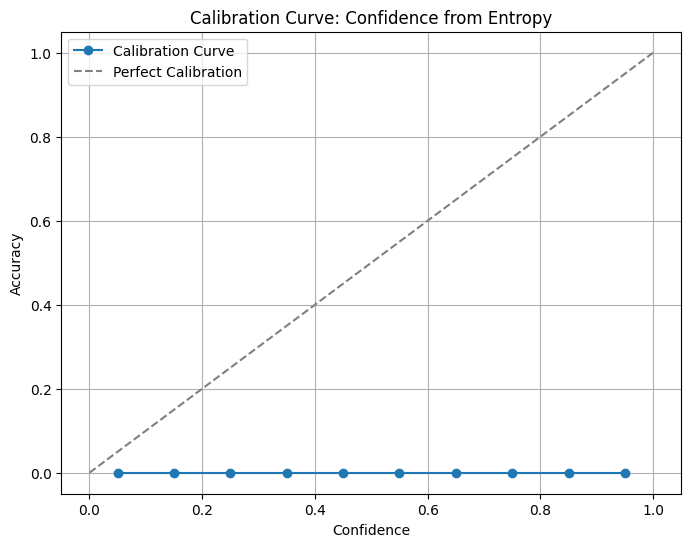

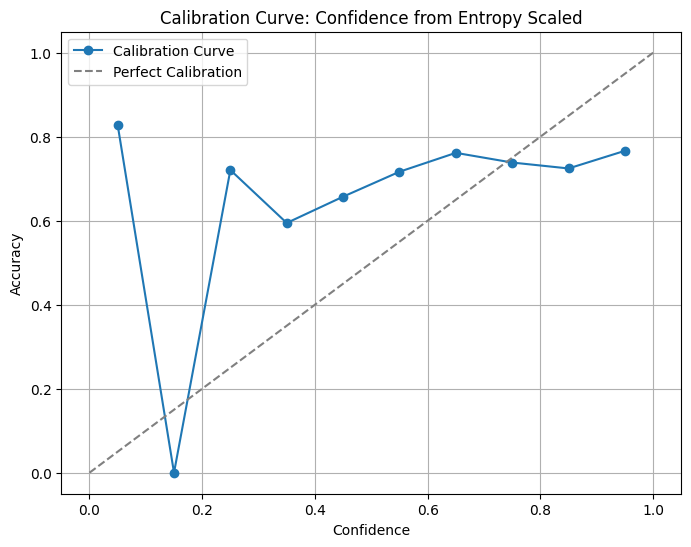

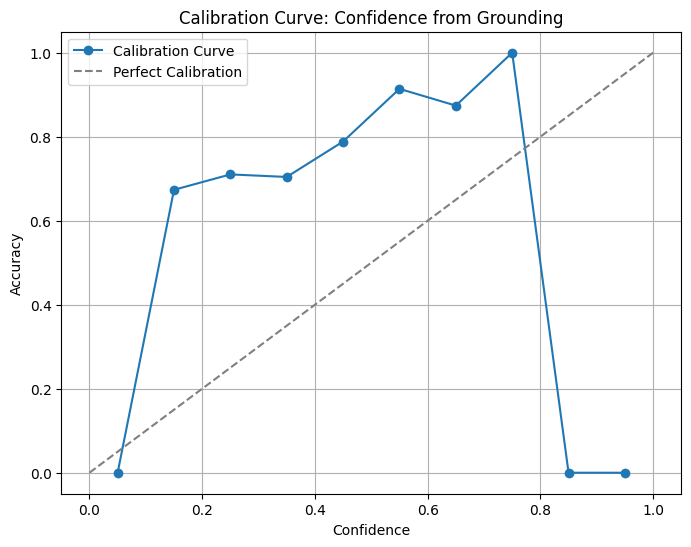

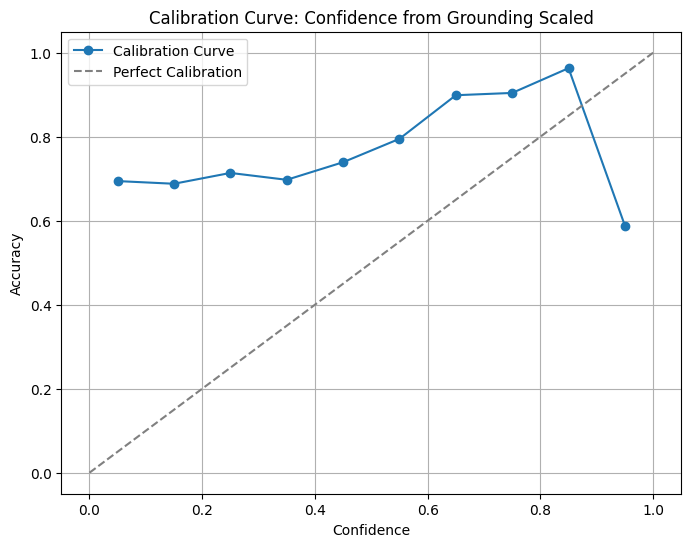

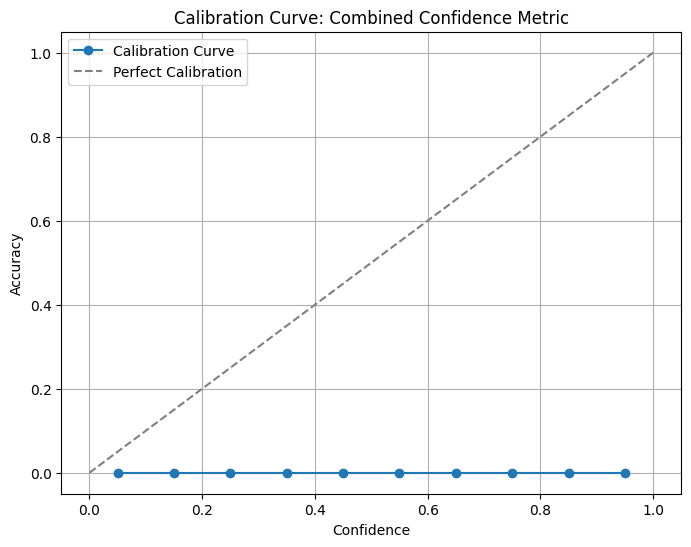

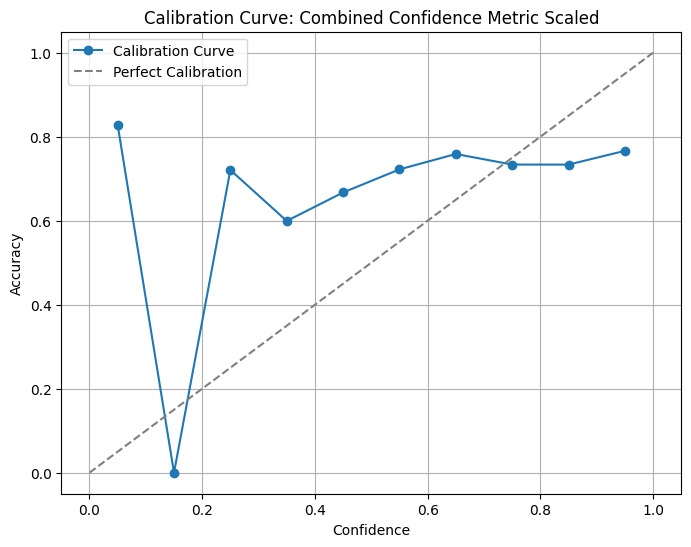

In [5]:
# Bin data by uncertainty
def bin_data(confidences, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

# Plot the calibration curve
def plot_calibration_curve(confidences, accuracies, title, num_bins=10):
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the calibration curves
plot_calibration_curve(confidences_from_entropy, accuracies, 'Calibration Curve: Confidence from Entropy', num_bins=10)
plot_calibration_curve(confidences_from_entropy_scaled, accuracies, 'Calibration Curve: Confidence from Entropy Scaled', num_bins=10)


plot_calibration_curve(1 - confidences_from_grounding, accuracies, 'Calibration Curve: Confidence from Grounding', num_bins=10)

plot_calibration_curve(1 - confidences_from_grounding_scaled, accuracies, 'Calibration Curve: Confidence from Grounding Scaled', num_bins=10)

plot_calibration_curve(combined_confidences, accuracies, 'Calibration Curve: Combined Confidence Metric', num_bins=10)
plot_calibration_curve(combined_confidences_scaled, accuracies, 'Calibration Curve: Combined Confidence Metric Scaled', num_bins=10)



In [ ]:
# Plot the histogram of confidences
def plot_confidence_histogram(confidences, title):
    plt.figure(figsize=(10, 5))
    plt.hist(confidences, bins=np.linspace(0, 1, 11))
    plt.xlabel('Confidence')
    plt.ylabel('Number of Samples')
    plt.title(title)
    plt.show()

# Plot histograms for each type of confidence
plot_confidence_histogram(entropy_confidences, 'Histogram of Entropy Confidences')
plot_confidence_histogram(confidence_metric_confidences, 'Histogram of Confidence Metric Confidences')
plot_confidence_histogram(combined_confidences, 'Histogram of Combined Confidences')

In [ ]:
# Plot the KDE distribution of confidences and accuracies
def plot_kde(confidences, accuracies, confidence_title, accuracy_title):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(confidences, color='r')
    plt.xlabel(confidence_title)
    plt.ylabel('Density')
    plt.xlim(0, 1)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(accuracies, bins=np.linspace(0, 1, 11))
    plt.xlabel('Accuracy')
    plt.ylabel('Number of Samples')
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.kdeplot(accuracies, color='r')
    plt.xlabel(accuracy_title)
    plt.ylabel('Density')
    plt.xlim(0, 1)
    plt.show()

# Plot KDEs for each type of confidence and accuracy
plot_kde(entropy_confidences, accuracies, 'KDE of Entropy Confidences', 'KDE of Accuracies')
plot_kde(confidence_metric_confidences, accuracies, 'KDE of Confidence Metric Confidences', 'KDE of Accuracies')
plot_kde(combined_confidences, accuracies, 'KDE of Combined Confidences', 'KDE of Accuracies')